# Nạp toàn bộ kết quả thực nghiệm của 6 mã cổ phiếu

Notebook này dành cho **Python 3.10**. Chọn kernel Python 3.10 rồi chạy **Run All**. Notebook tự tìm 6 thư mục `ACB`, `FPT`, `GAS`, `HPG`, `SSI`, `VCB`; nạp mọi CSV và NPZ vào bộ nhớ; đồng thời lập danh mục ảnh PNG và checkpoint PT.

Biến kết quả chính là `all_data`. Notebook không sửa các tệp kết quả gốc.

In [9]:
# Kiểm tra Python 3.10 và tự cài các thư viện đọc dữ liệu nếu còn thiếu.
import sys
import subprocess
import importlib.util

if sys.version_info[:2] != (3, 10):
    raise RuntimeError(
        f'Notebook yêu cầu Python 3.10, kernel hiện tại là {sys.version.split()[0]}. '
        'Hãy đổi kernel sang Python 3.10 rồi chạy lại.'
    )

required = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib'}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])

from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', 120)
print(f'OK - Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__}')

OK - Python 3.10.0 | pandas 2.2.3 | numpy 2.2.6


In [10]:
# Cấu hình và tự xác định thư mục gốc, kể cả khi Jupyter được mở từ thư mục khác.
TICKERS = ('ACB', 'FPT', 'GAS', 'HPG', 'SSI', 'VCB')
SCENARIOS = ('good', 'bad')

def find_data_root(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    notebook_dir = Path.cwd().resolve()
    if notebook_dir not in candidates:
        candidates.insert(0, notebook_dir)
    for candidate in candidates:
        if all((candidate / ticker).is_dir() for ticker in TICKERS):
            return candidate
    raise FileNotFoundError(
        'Không tìm thấy thư mục chứa đủ: ' + ', '.join(TICKERS) +
        '. Hãy đặt notebook trong thư mục V-Eperiment Results.'
    )

DATA_ROOT = find_data_root(Path.cwd())
print('Thư mục dữ liệu:', DATA_ROOT)

Thư mục dữ liệu: D:\NCKH\JOURNAL_2026\V-Eperiment Results


In [11]:
# Lập danh mục toàn bộ tệp nằm trong 6 thư mục.
catalog_rows = []
for ticker in TICKERS:
    ticker_dir = DATA_ROOT / ticker
    for path in sorted(p for p in ticker_dir.rglob('*') if p.is_file()):
        relative = path.relative_to(DATA_ROOT)
        scenario = relative.parts[1] if len(relative.parts) > 2 and relative.parts[1] in SCENARIOS else None
        catalog_rows.append({
            'ticker': ticker,
            'scenario': scenario,
            'name': path.name,
            'extension': path.suffix.lower(),
            'size_bytes': path.stat().st_size,
            'relative_path': relative.as_posix(),
            'path': path,
        })

file_catalog = pd.DataFrame(catalog_rows)
display(file_catalog.groupby(['ticker', 'extension'], dropna=False).size().unstack(fill_value=0))
print(f'Tổng số tệp được tìm thấy: {len(file_catalog):,}')

extension,.csv,.npz,.png,.pt
ticker,,,,
ACB,14,2,10,1
FPT,14,2,9,1
GAS,14,2,10,1
HPG,14,2,10,1
SSI,14,2,10,1
VCB,14,2,10,1


Tổng số tệp được tìm thấy: 161


In [12]:
# Nạp TOÀN BỘ CSV.
# csv_data[ticker][scenario][tên_dataset] -> một DataFrame gốc.
csv_data = {ticker: {scenario: {} for scenario in SCENARIOS} for ticker in TICKERS}
csv_frames_by_name = {}
csv_load_log = []

csv_files = file_catalog[file_catalog['extension'].eq('.csv')]
for row in csv_files.itertuples(index=False):
    if row.scenario not in SCENARIOS:
        raise ValueError(f'CSV không thuộc good/bad: {row.relative_path}')
    dataset_name = Path(row.name).stem
    frame = pd.read_csv(row.path, low_memory=False)
    csv_data[row.ticker][row.scenario][dataset_name] = frame

    enriched = frame.copy()
    enriched.insert(0, '_source_file', row.relative_path)
    enriched.insert(0, '_scenario', row.scenario)
    enriched.insert(0, '_ticker_folder', row.ticker)
    csv_frames_by_name.setdefault(dataset_name, []).append(enriched)
    csv_load_log.append({
        'ticker': row.ticker, 'scenario': row.scenario, 'dataset': dataset_name,
        'rows': len(frame), 'columns': len(frame.columns), 'file': row.relative_path
    })

combined = {
    name: pd.concat(frames, ignore_index=True, sort=False)
    for name, frames in csv_frames_by_name.items()
}
csv_inventory = pd.DataFrame(csv_load_log).sort_values(['dataset', 'ticker', 'scenario']).reset_index(drop=True)
display(csv_inventory.groupby('dataset').agg(files=('file', 'count'), rows=('rows', 'sum'), max_columns=('columns', 'max')))
print(f'Đã nạp {len(csv_inventory)} CSV, tổng cộng {csv_inventory.rows.sum():,} dòng.')

,files,rows,max_columns
dataset,,,
buy_and_hold_metrics,12,12,25
buy_and_hold_portfolio,12,7507,6
rl_episode_curves,12,43200,30
rl_losses,12,393600,7
rl_metrics,12,480,79
rl_test_portfolios,12,300280,7
three_strategy_summary,12,36,50


Đã nạp 84 CSV, tổng cộng 745,115 dòng.


In [13]:
# Nạp toàn bộ scaler NPZ; lập danh sách ảnh và model checkpoint.
scalers = {ticker: {} for ticker in TICKERS}
npz_inventory_rows = []

for row in file_catalog[file_catalog['extension'].eq('.npz')].itertuples(index=False):
    with np.load(row.path, allow_pickle=False) as archive:
        arrays = {key: archive[key].copy() for key in archive.files}
    scalers[row.ticker][row.scenario] = arrays
    npz_inventory_rows.append({
        'ticker': row.ticker, 'scenario': row.scenario, 'file': row.relative_path,
        'array_keys': tuple(arrays),
        'shapes': {key: value.shape for key, value in arrays.items()},
    })

npz_inventory = pd.DataFrame(npz_inventory_rows)
image_files = file_catalog.loc[file_catalog['extension'].eq('.png')].reset_index(drop=True)
checkpoint_files = file_catalog.loc[file_catalog['extension'].eq('.pt')].reset_index(drop=True)

display(npz_inventory)
print(f'NPZ: {len(npz_inventory)} | PNG: {len(image_files)} | PT: {len(checkpoint_files)}')
print('Lưu ý: checkpoint PT được lập danh mục nhưng không tự giải tuần tự hóa để tránh yêu cầu PyTorch và rủi ro pickle.')

,ticker,scenario,file,array_keys,shapes
0,ACB,bad,ACB/bad/frozen_scaler_train_only.npz,"(mean, std)","{'mean': (7,), 'std': (7,)}"
1,ACB,good,ACB/good/frozen_scaler_train_only.npz,"(mean, std)","{'mean': (7,), 'std': (7,)}"
2,FPT,bad,FPT/bad/frozen_scaler_train_only.npz,"(mean, std)","{'mean': (7,), 'std': (7,)}"
3,FPT,good,FPT/good/frozen_scaler_train_only.npz,"(mean, std)","{'mean': (7,), 'std': (7,)}"
4,GAS,bad,GAS/bad/frozen_scaler_train_only.npz,"(mean, std)","{'mean': (7,), 'std': (7,)}"
5,GAS,good,GAS/good/frozen_scaler_train_only.npz,"(mean, std)","{'mean': (7,), 'std': (7,)}"
6,HPG,bad,HPG/bad/frozen_scaler_train_only.npz,"(mean, std)","{'mean': (7,), 'std': (7,)}"
7,HPG,good,HPG/good/frozen_scaler_train_only.npz,"(mean, std)","{'mean': (7,), 'std': (7,)}"
8,SSI,bad,SSI/bad/frozen_scaler_train_only.npz,"(mean, std)","{'mean': (7,), 'std': (7,)}"
9,SSI,good,SSI/good/frozen_scaler_train_only.npz,"(mean, std)","{'mean': (7,), 'std': (7,)}"


NPZ: 12 | PNG: 59 | PT: 6
Lưu ý: checkpoint PT được lập danh mục nhưng không tự giải tuần tự hóa để tránh yêu cầu PyTorch và rủi ro pickle.


In [14]:
# Kiểm tra tính đầy đủ và gom mọi kết quả vào một biến duy nhất.
expected_dataset_names = {
    'buy_and_hold_metrics', 'buy_and_hold_portfolio', 'rl_episode_curves',
    'rl_losses', 'rl_metrics', 'rl_test_portfolios', 'three_strategy_summary'
}
issues = []
for ticker in TICKERS:
    for scenario in SCENARIOS:
        found = set(csv_data[ticker][scenario])
        missing = expected_dataset_names - found
        if missing:
            issues.append(f'{ticker}/{scenario} thiếu CSV: {sorted(missing)}')
        if scenario not in scalers[ticker]:
            issues.append(f'{ticker}/{scenario} thiếu scaler NPZ')

all_data = {
    'root': DATA_ROOT,
    'tickers': TICKERS,
    'scenarios': SCENARIOS,
    'catalog': file_catalog,
    'csv': csv_data,
    'combined': combined,
    'csv_inventory': csv_inventory,
    'scalers': scalers,
    'npz_inventory': npz_inventory,
    'images': image_files,
    'checkpoints': checkpoint_files,
}

if issues:
    print('CẢNH BÁO:')
    print('\n'.join(f'- {issue}' for issue in issues))
else:
    print('HOÀN TẤT: Đủ 6 mã x 2 kịch bản, đủ 7 bộ CSV và scaler cho mỗi kịch bản.')
print('Các bảng đã gộp:', ', '.join(sorted(combined)))

HOÀN TẤT: Đủ 6 mã x 2 kịch bản, đủ 7 bộ CSV và scaler cho mỗi kịch bản.
Các bảng đã gộp: buy_and_hold_metrics, buy_and_hold_portfolio, rl_episode_curves, rl_losses, rl_metrics, rl_test_portfolios, three_strategy_summary


## Cách truy cập nhanh

- Một bảng gốc: `all_data['csv']['ACB']['good']['rl_metrics']`
- Bảng gộp cả 6 mã và hai kịch bản: `all_data['combined']['rl_metrics']`
- Scaler: `all_data['scalers']['ACB']['good']`
- Danh mục ảnh: `all_data['images']`
- Danh mục checkpoint: `all_data['checkpoints']`
- Danh mục tất cả tệp: `all_data['catalog']`

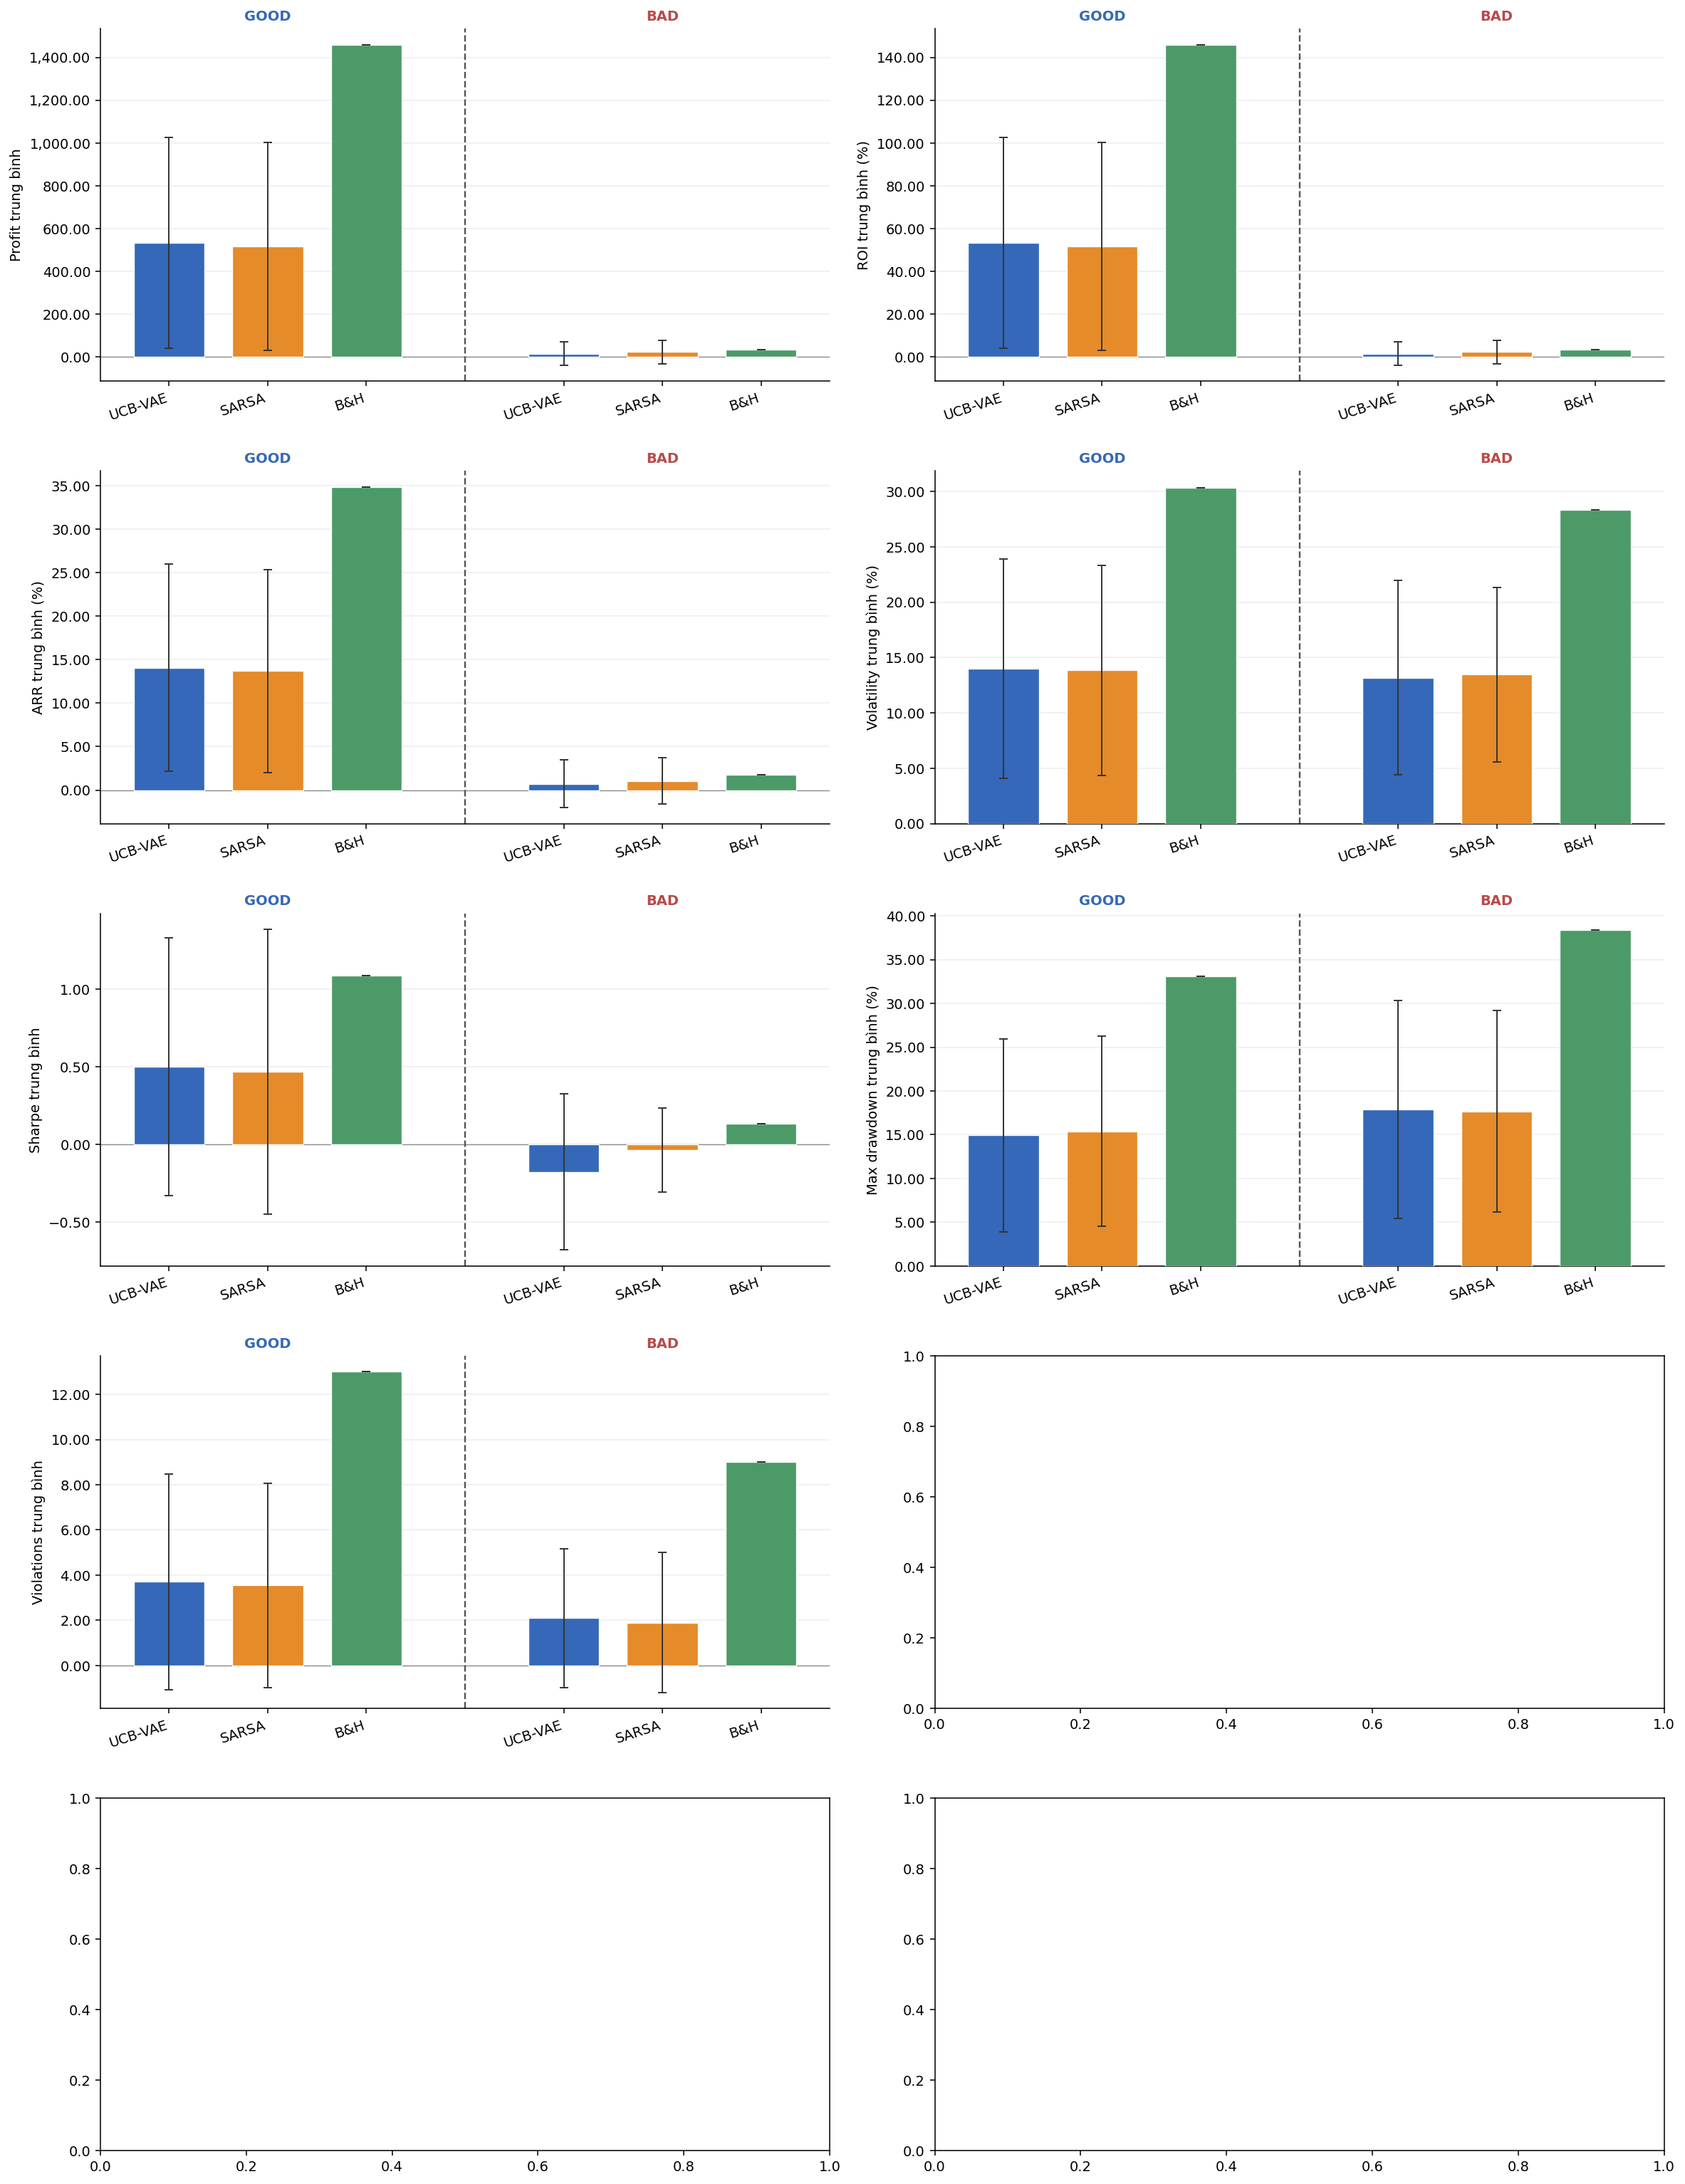

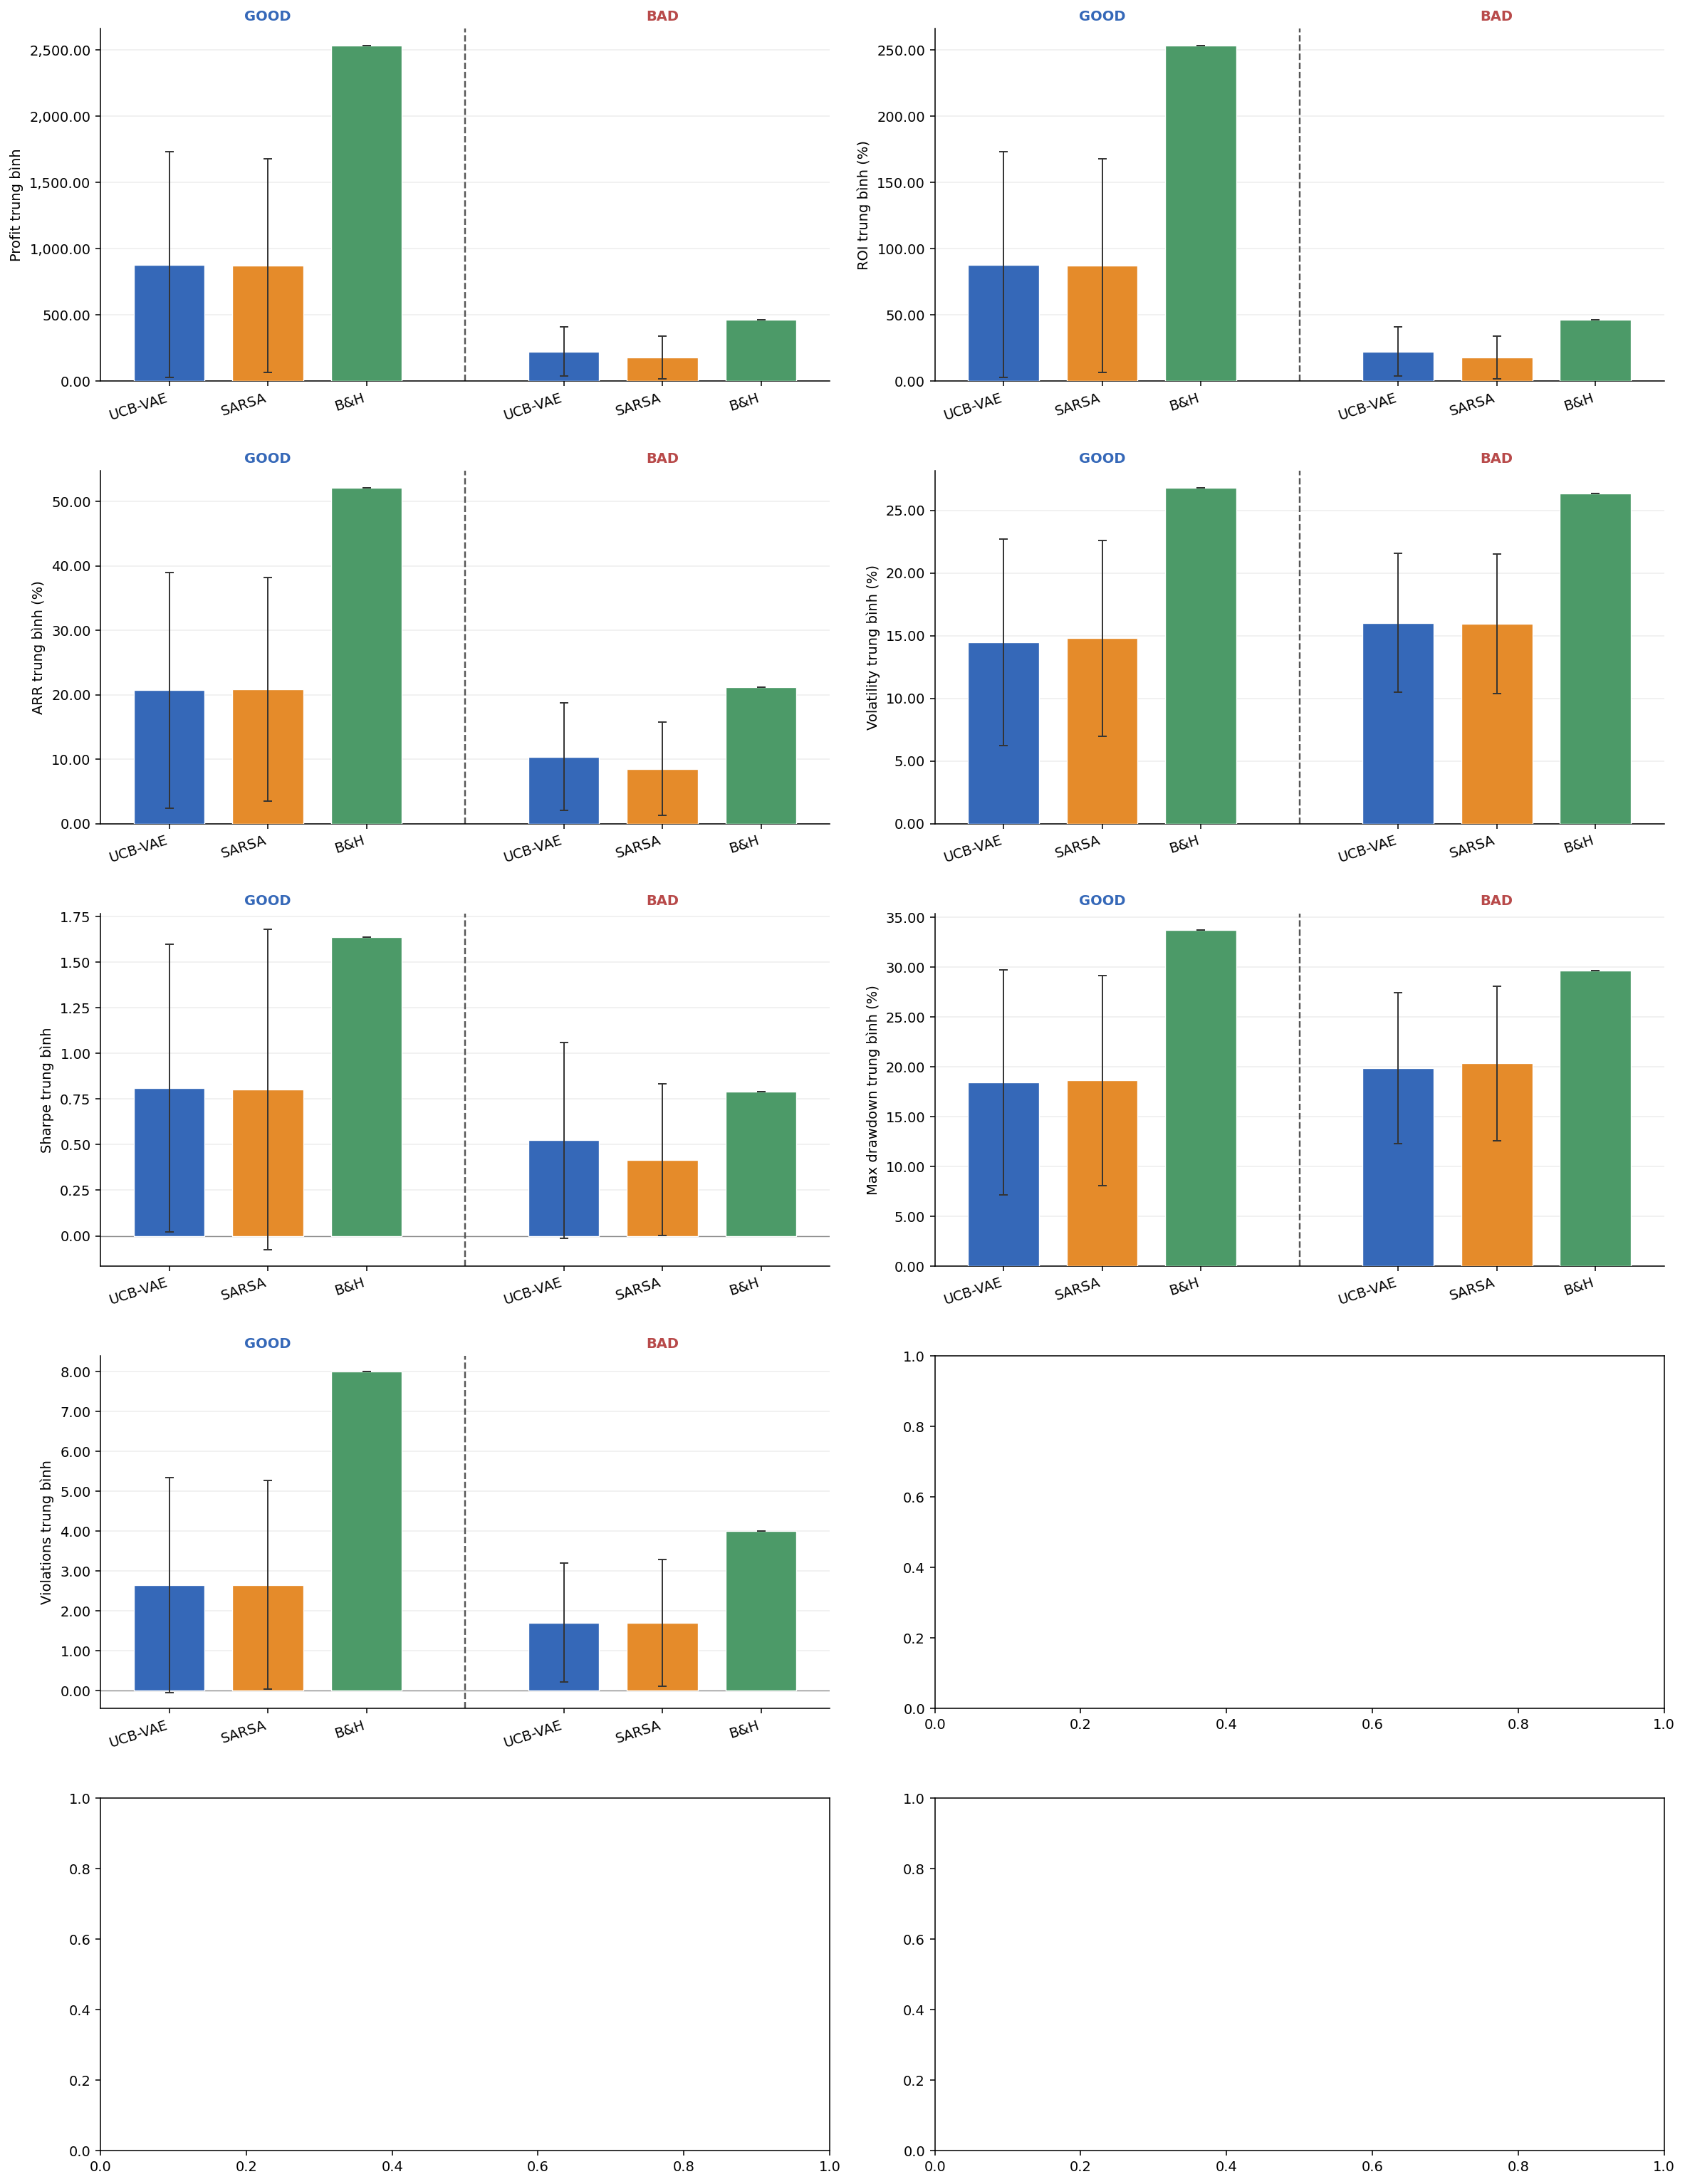

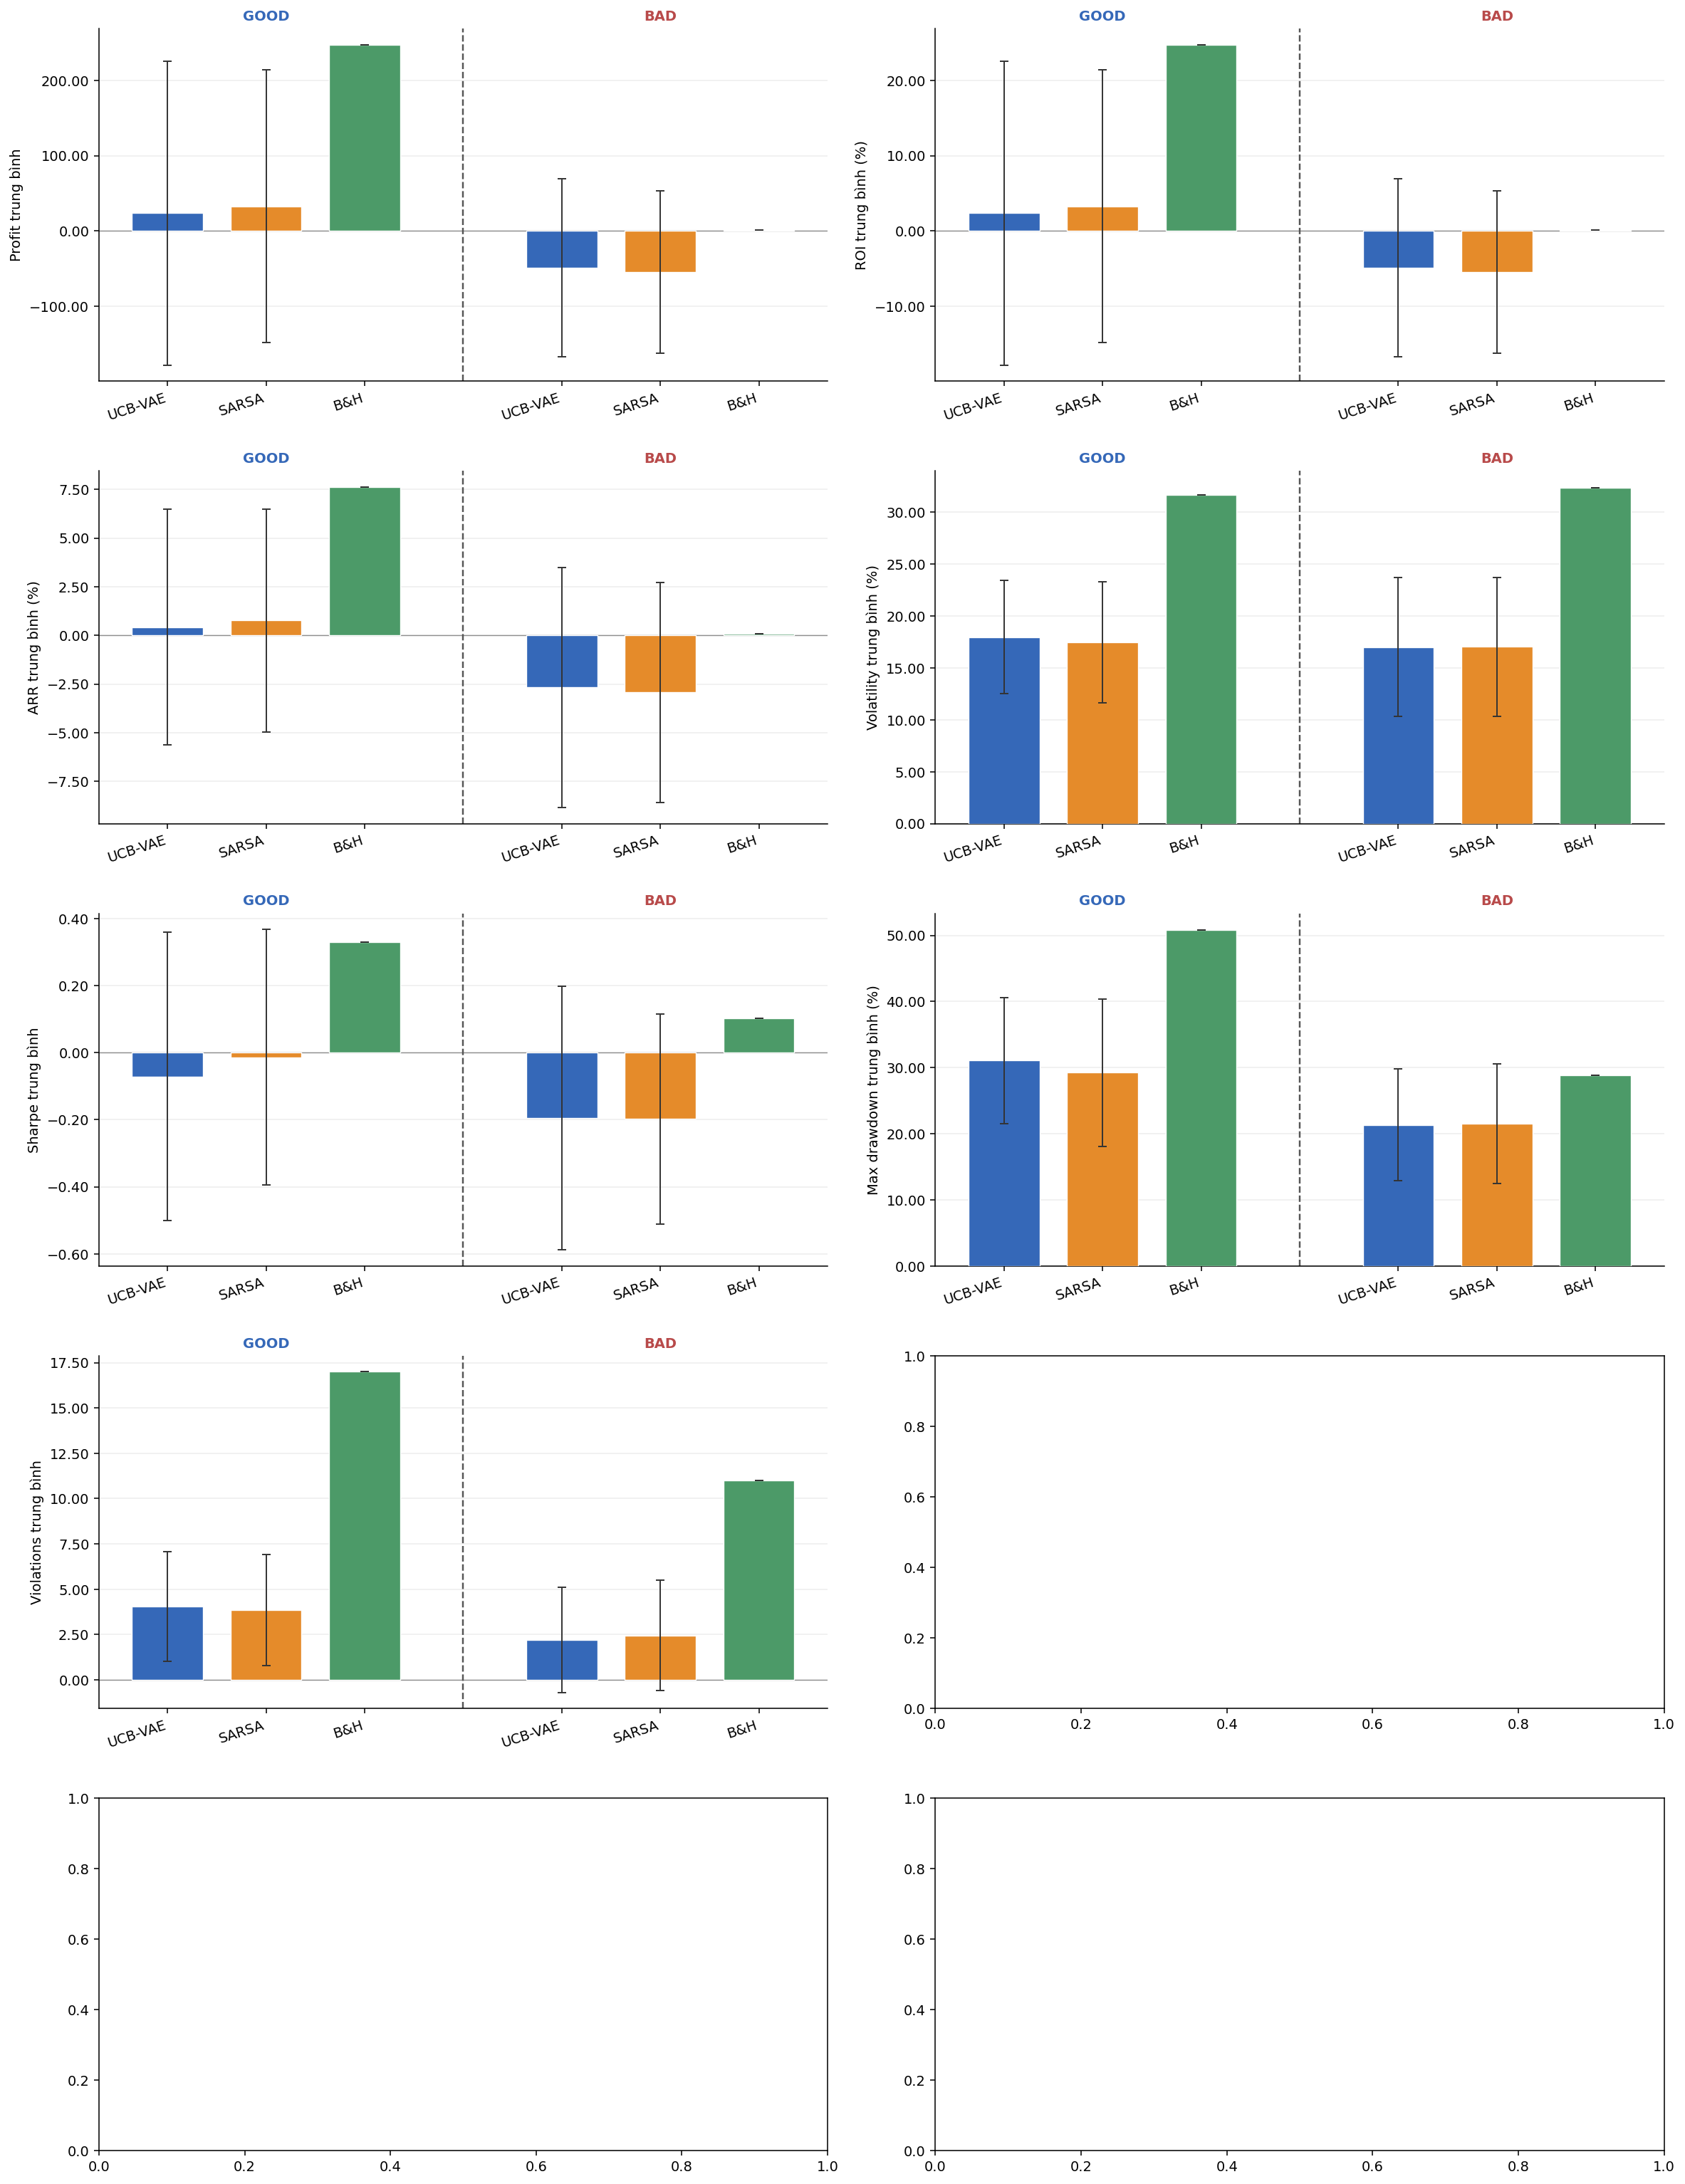

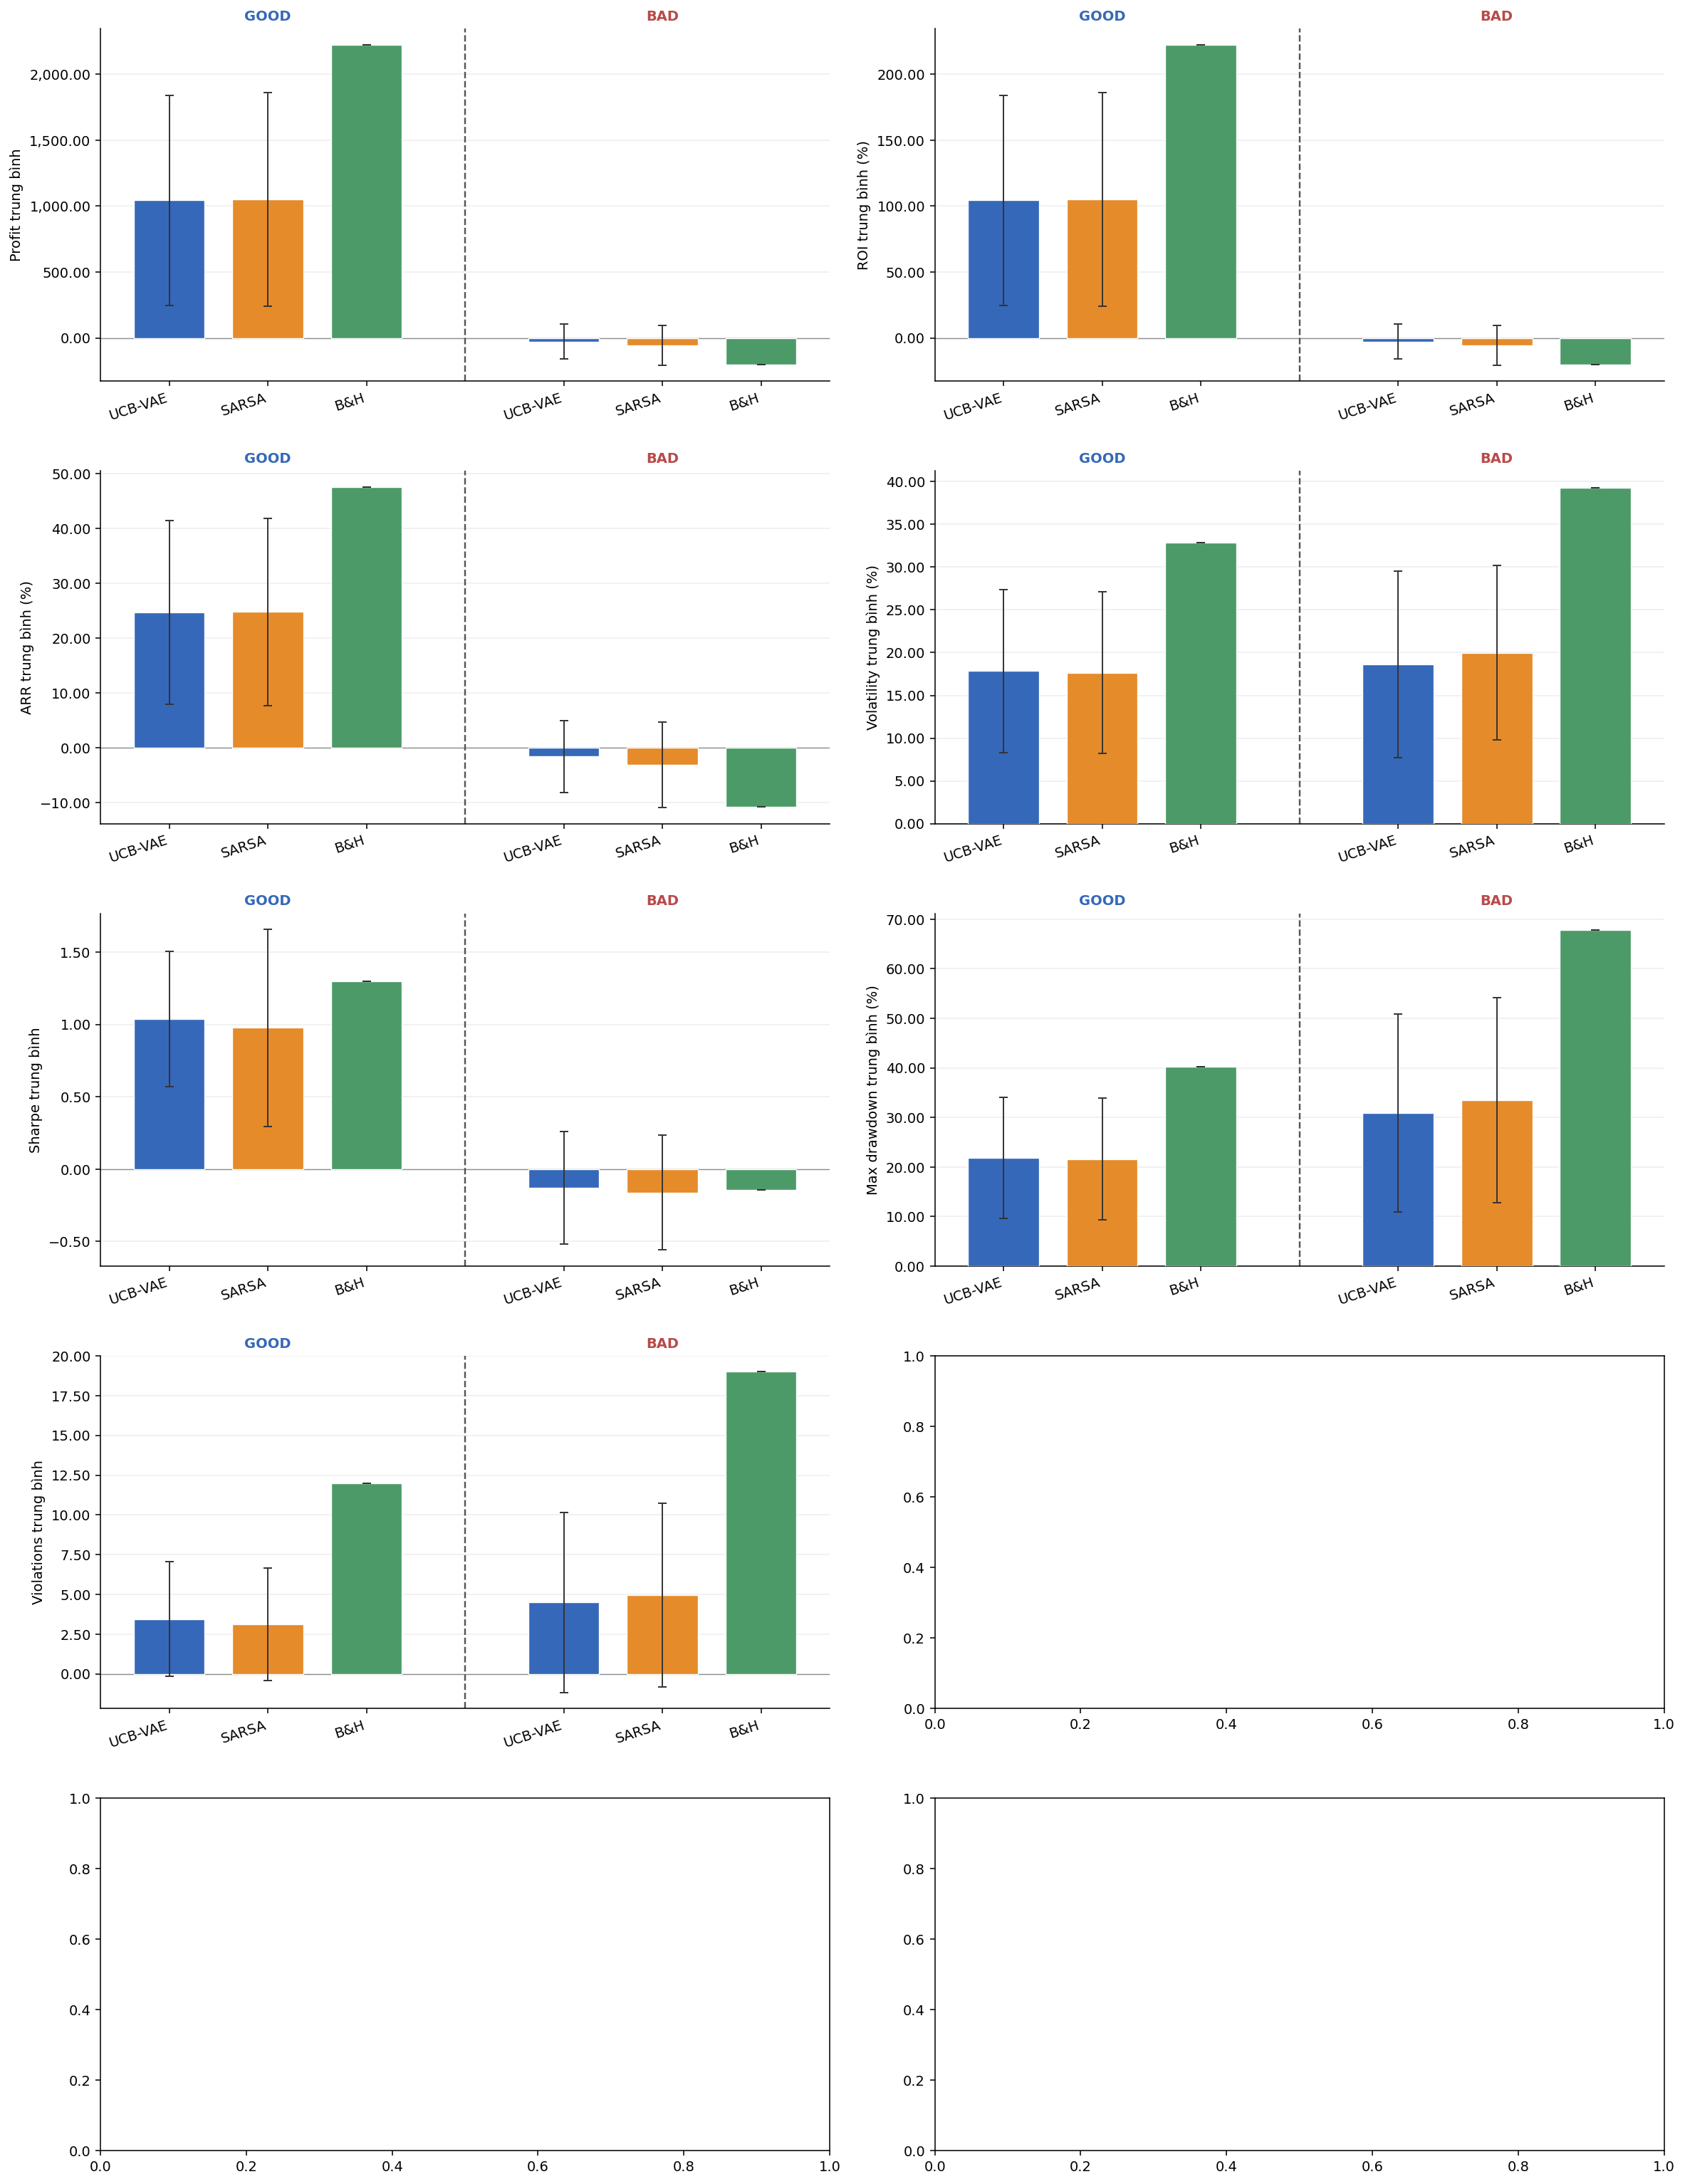

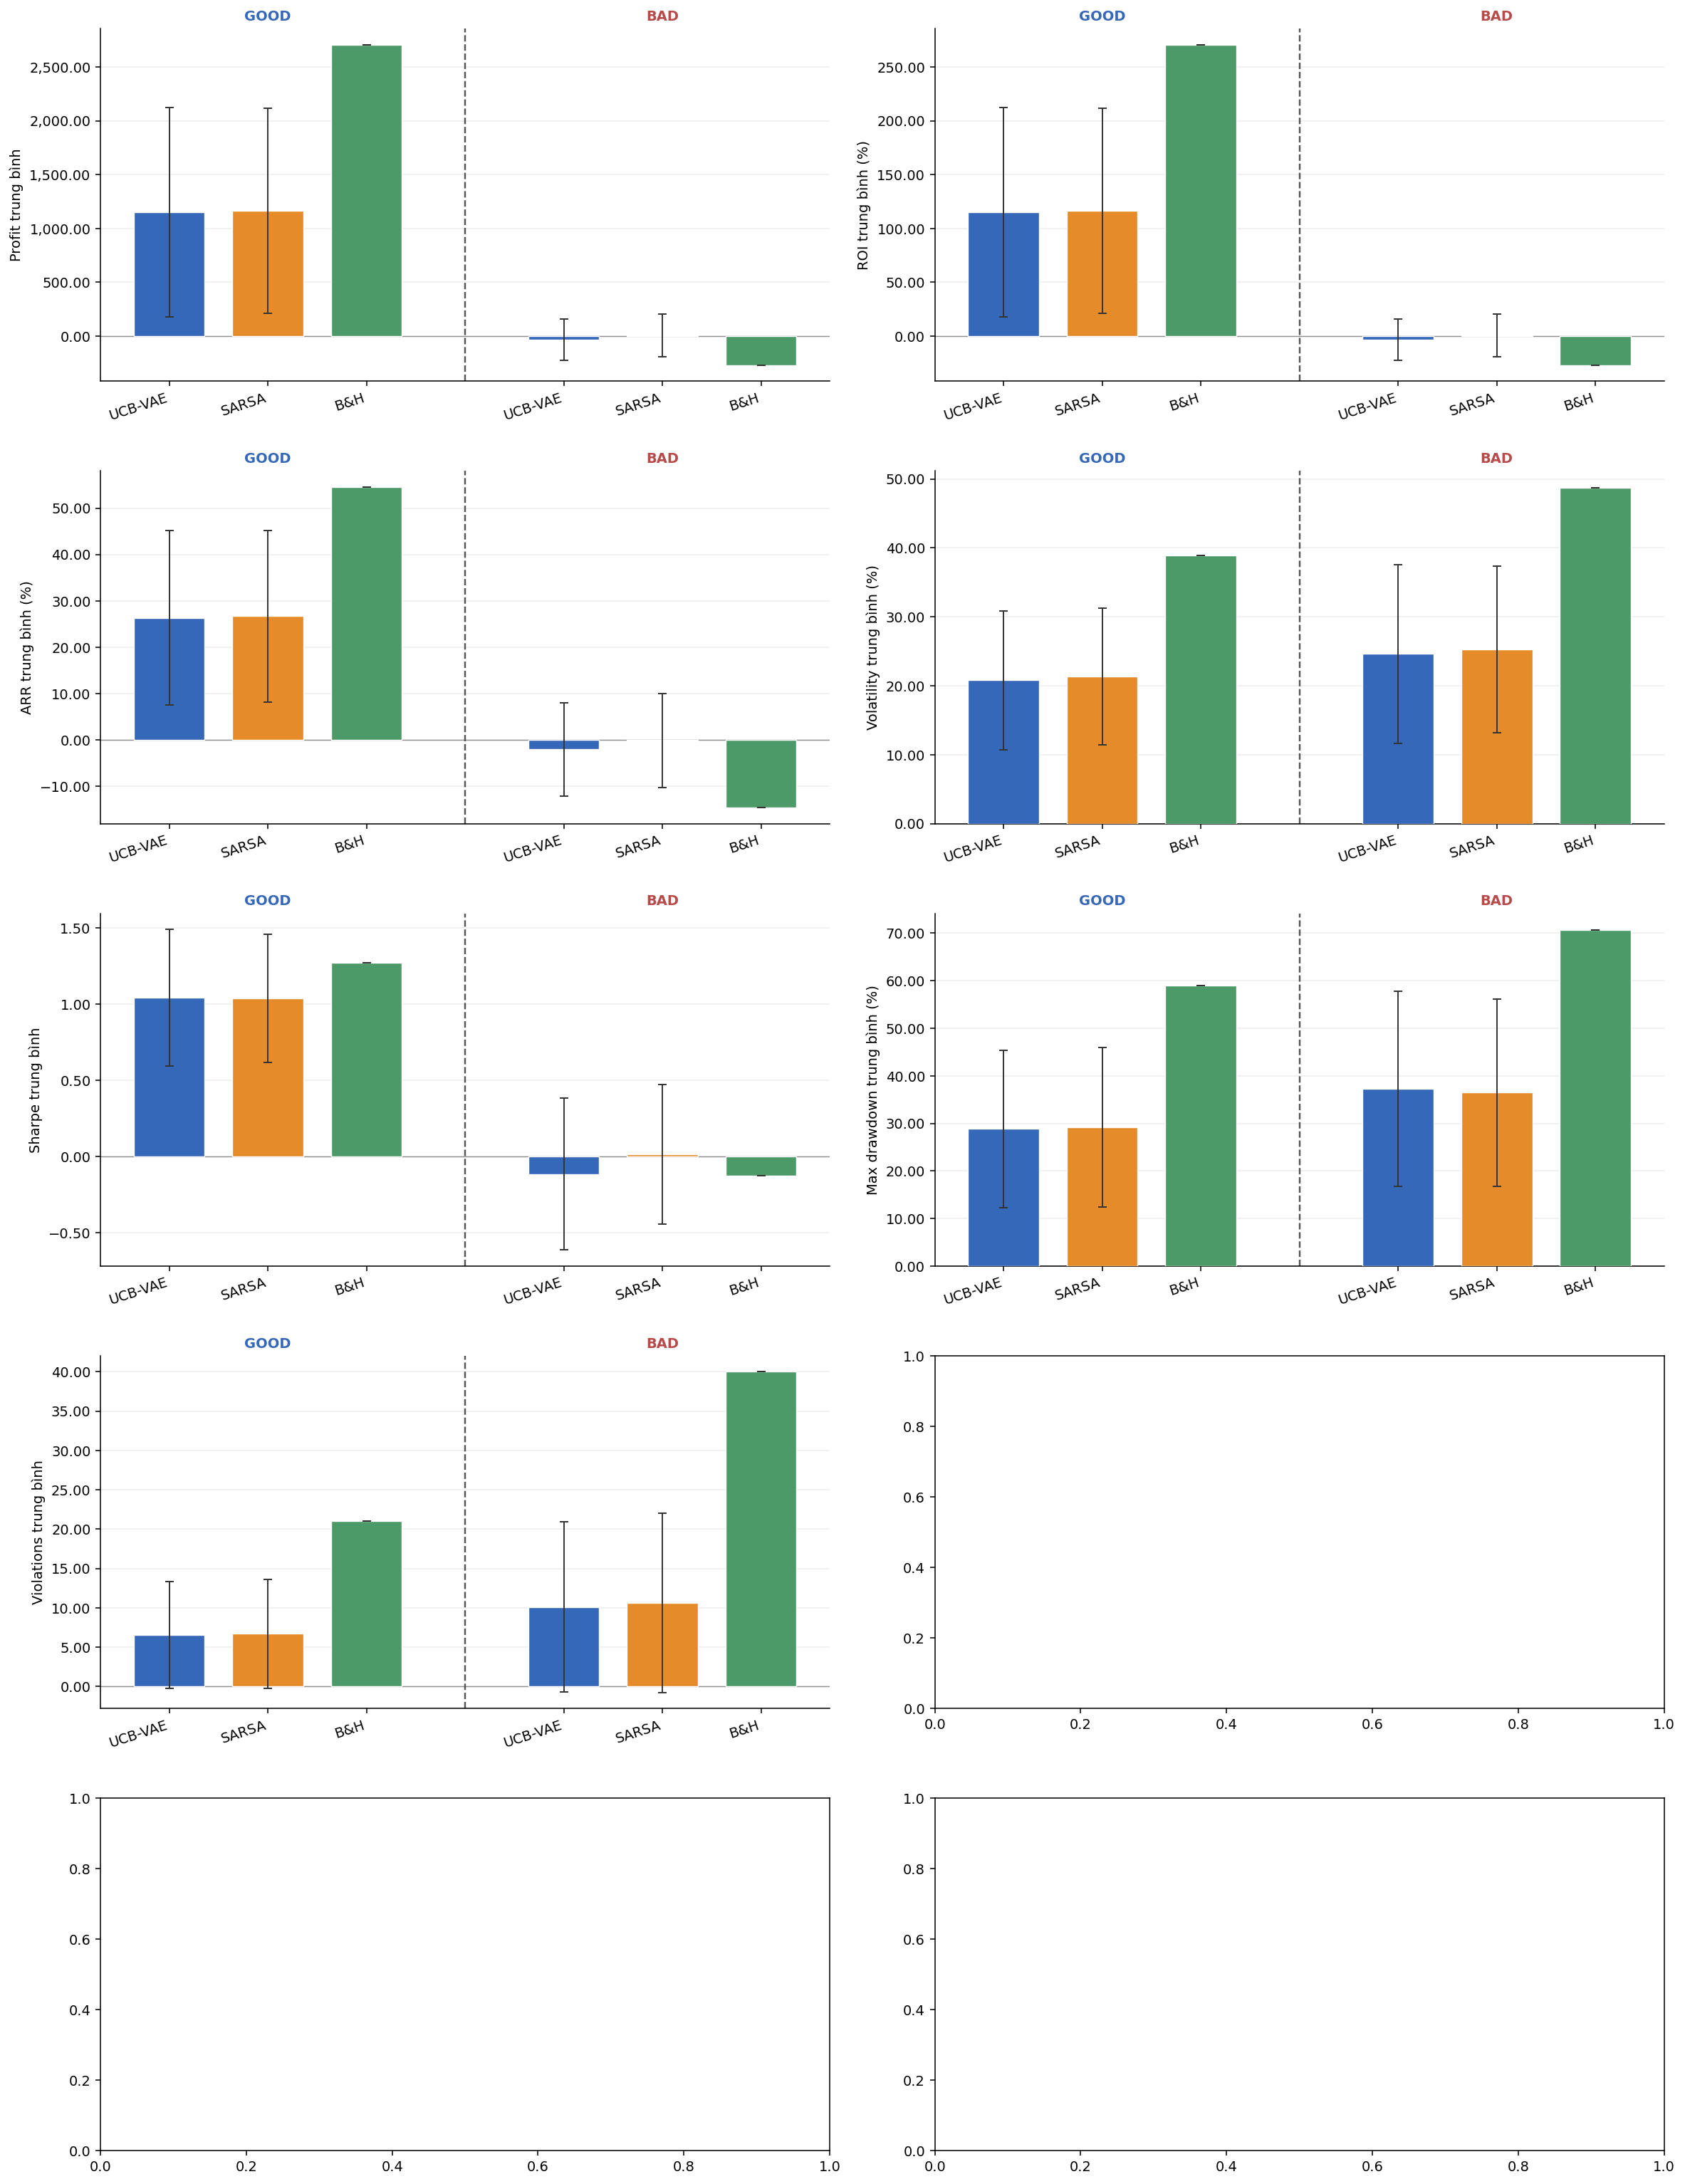

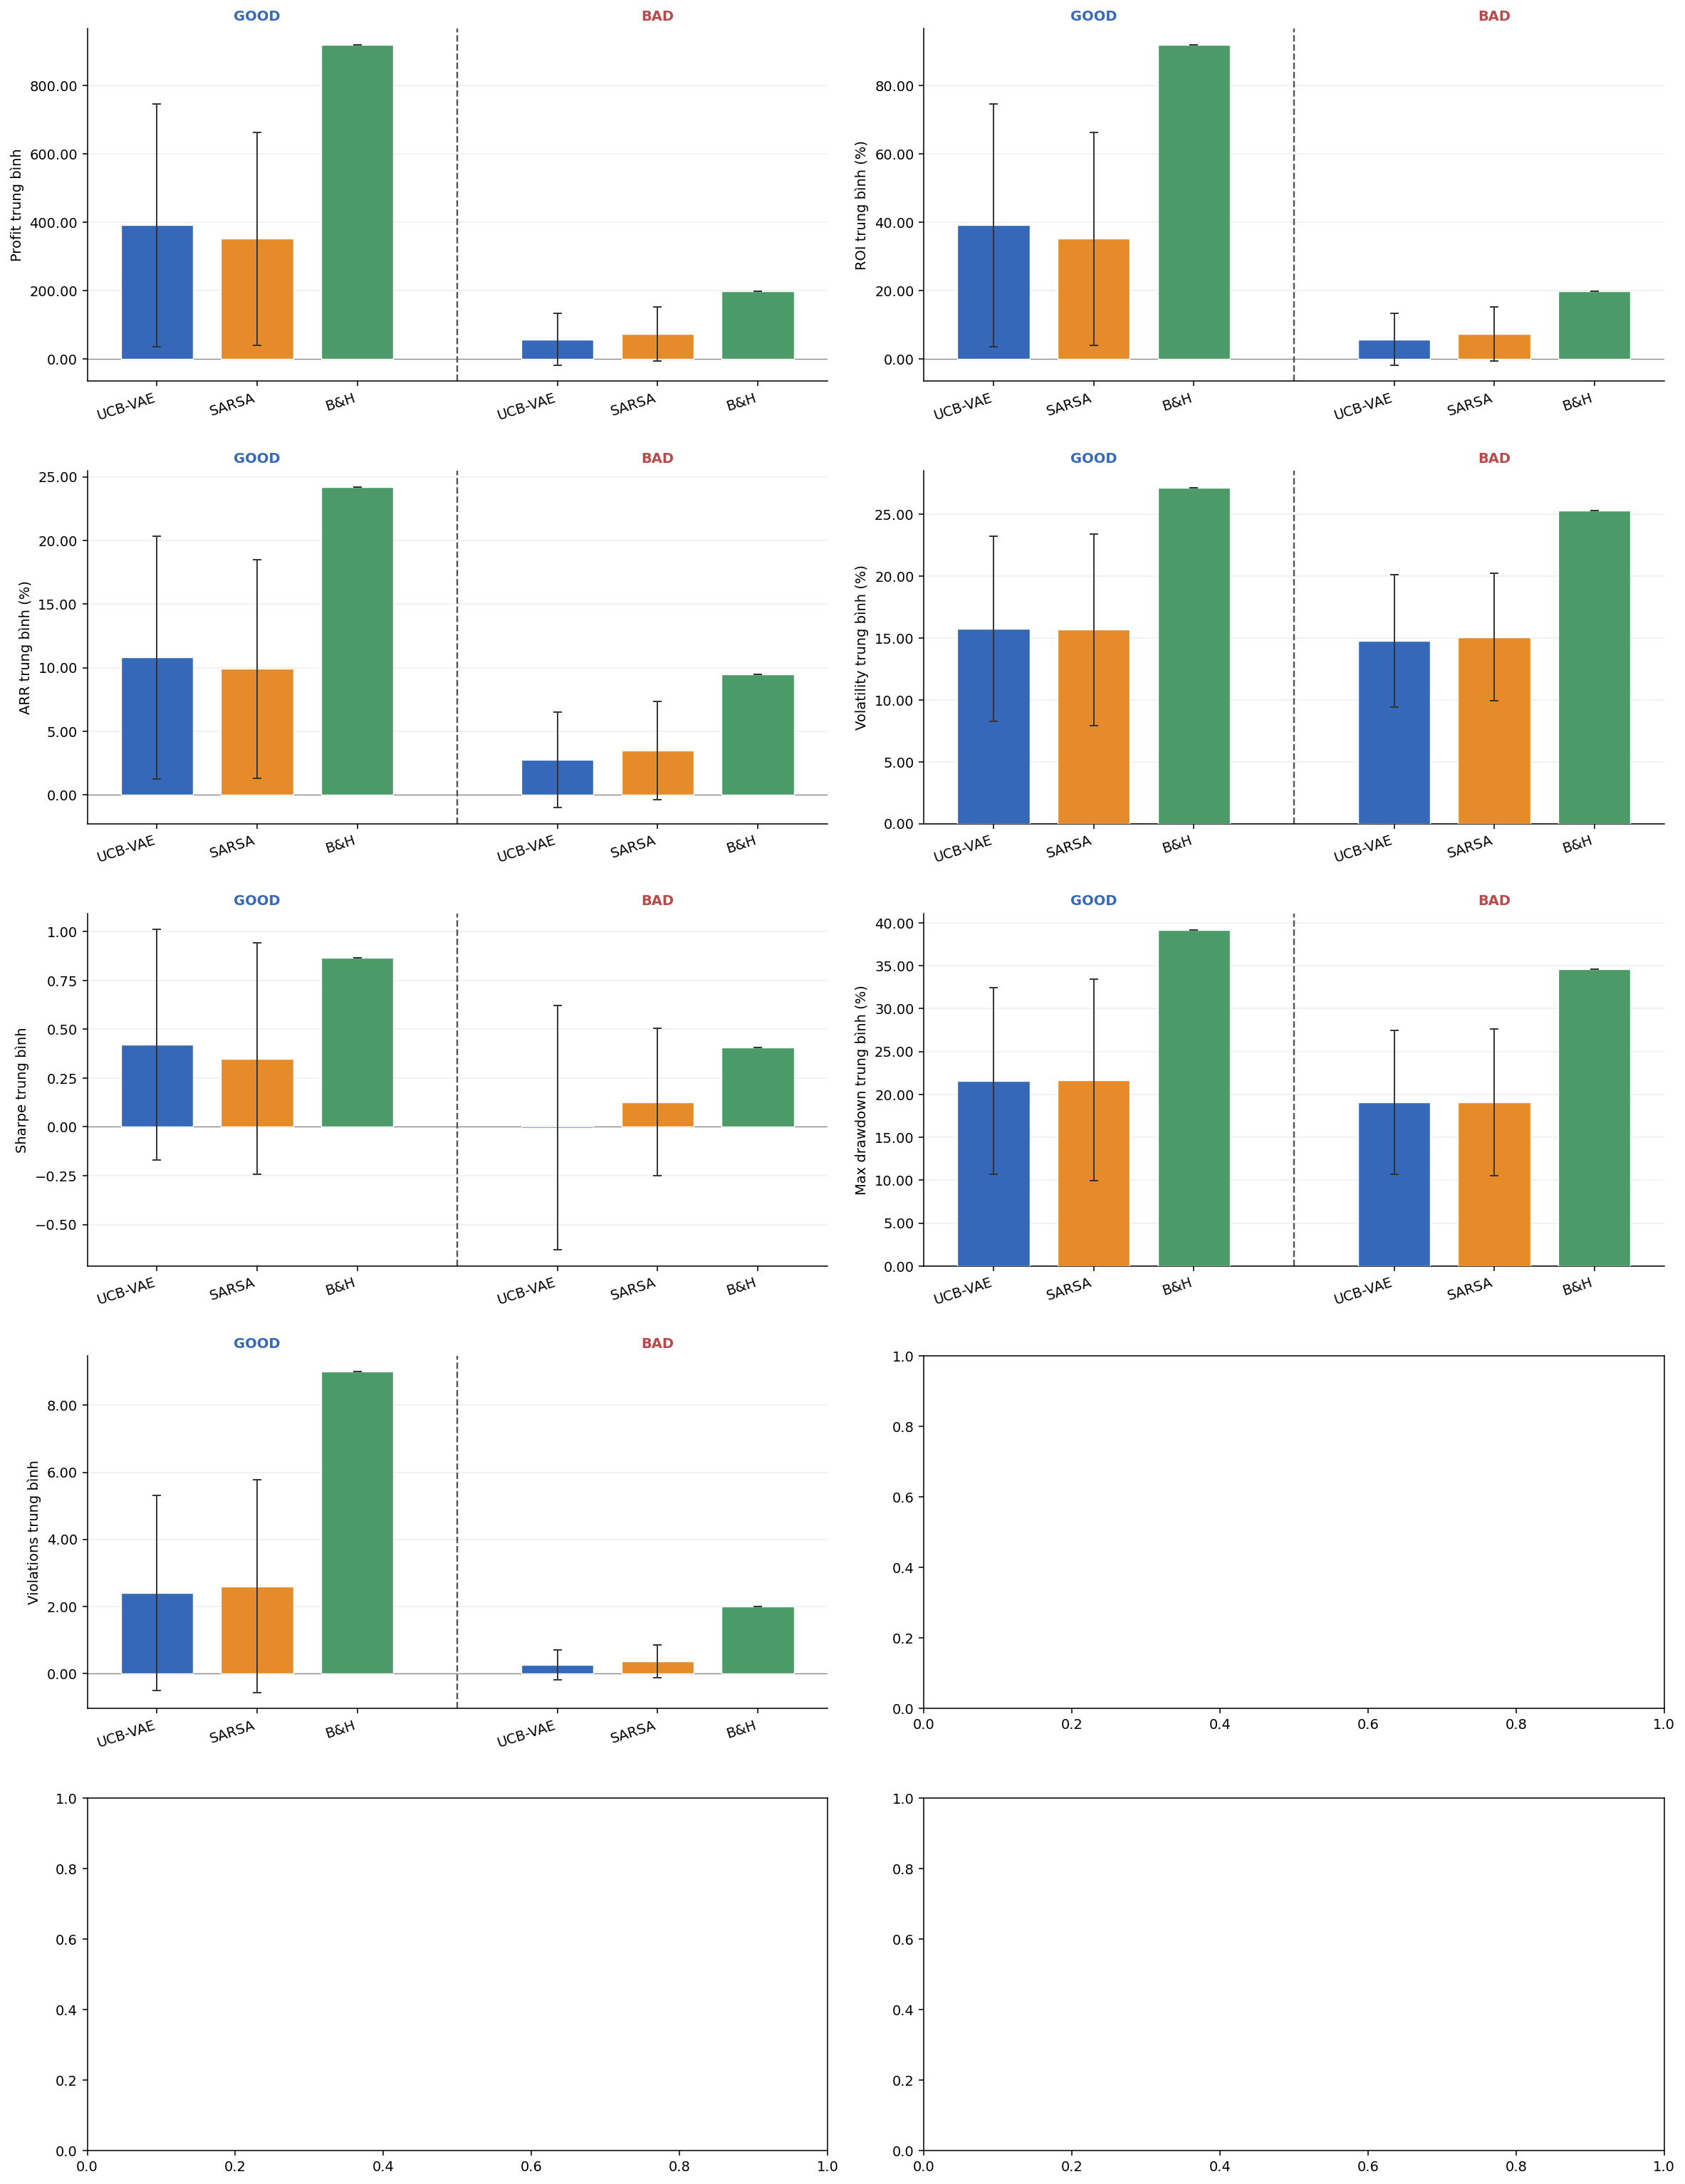

In [17]:
# Vẽ một hình riêng cho từng mã; chỉ xuất hình, không tạo bảng trung gian trên output.
from IPython import get_ipython
ipython_shell = get_ipython()
if ipython_shell is not None:
    ipython_shell.run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

summary = all_data['combined']['three_strategy_summary'].copy()

metrics = {
    'test_profit_mean': 'Profit trung bình',
    'test_roi_mean': 'ROI trung bình (%)',
    'test_arr_mean': 'ARR trung bình (%)',
    'test_volatility_mean': 'Volatility trung bình (%)',
    'test_sharpe_mean': 'Sharpe trung bình',
    'test_max_drawdown_mean': 'Max drawdown trung bình (%)',
    'test_violations_mean': 'Violations trung bình'
}
strategy_order = [
    'Uncertainty-Aware UCB-VAE (env_v3)',
    'Deep SARSA Epsilon-Greedy',
    'Buy-and-Hold',
]
strategy_labels = ['UCB-VAE', 'SARSA', 'B&H']
strategy_colors = ['#3568B8', '#E58B2A', '#4C9A68']
x_good = np.arange(3, dtype=float)
x_bad = np.arange(3, dtype=float) + 4.0
x_all = np.concatenate([x_good, x_bad])
x_labels = strategy_labels + strategy_labels

for ticker in TICKERS:
    ticker_data = summary[summary['_ticker_folder'].eq(ticker)]
    fig, axes = plt.subplots(5, 2, figsize=(17, 22), dpi=140)

    for ax, (metric, y_label) in zip(axes.flat, metrics.items()):
        values_by_scenario = []
        errors_by_scenario = []
        std_column = metric.replace('_mean', '_std') if metric.endswith('_mean') else None

        for scenario in SCENARIOS:
            block = (
                ticker_data[ticker_data['_scenario'].eq(scenario)]
                .set_index('model')
                .reindex(strategy_order)
            )
            values_by_scenario.append(pd.to_numeric(block[metric], errors='coerce').to_numpy())
            if std_column and std_column in block.columns:
                errors_by_scenario.append(
                    pd.to_numeric(block[std_column], errors='coerce').fillna(0).to_numpy()
                )
            else:
                errors_by_scenario.append(None)

        for positions, values, errors in zip(
            (x_good, x_bad), values_by_scenario, errors_by_scenario
        ):
            bars = ax.bar(
                positions, values, width=0.72, color=strategy_colors,
                yerr=errors, capsize=3 if errors is not None else 0,
                edgecolor='white', linewidth=0.7, zorder=3,
                error_kw={'elinewidth': 1, 'ecolor': '#333333'},
            )
            for bar_index, (bar, value) in enumerate(zip(bars, values)):
                if not np.isfinite(value):
                    continue
                if errors is not None and np.isfinite(errors[bar_index]):
                    error = float(errors[bar_index])
                    label = f'{value:,.2f}\n±{error:,.2f}'
                    label_y = value + error if value >= 0 else value - error
                else:
                    label = f'{value:,.2f}'
                    label_y = value
                ax.annotate(
                    label,
                    xy=(bar.get_x() + bar.get_width() / 2, label_y),
                    xytext=(0, 4 if value >= 0 else -4),
                    textcoords='offset points',
                    ha='center',
                    va='bottom' if value >= 0 else 'top',
                    fontsize=7.2,
                    color='#222222',
                    clip_on=False,
                )

        ax.axvline(3.0, color='#555555', linewidth=1.25, linestyle='--', zorder=2)
        ax.axhline(0, color='#888888', linewidth=0.7, zorder=1)
        ax.text(1.0, 1.015, 'GOOD', transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#3568B8')
        ax.text(5.0, 1.015, 'BAD', transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=10, fontweight='bold', color='#B84A4A')
        ax.set_ylabel(y_label, fontsize=10)
        ax.set_xticks(x_all, x_labels, rotation=18, ha='right')
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.2f}'))
        ax.margins(y=0.20)
        ax.grid(axis='y', alpha=0.22, linewidth=0.8, zorder=0)
        ax.spines[['top', 'right']].set_visible(False)

    fig.tight_layout(h_pad=2.2, w_pad=2.0)
    plt.show()

In [16]:
# Ví dụ xem nhanh bảng chỉ số RL đã gộp.
display(all_data['combined']['rl_metrics'].head())

,_ticker_folder,_scenario,_source_file,ticker,period,model_key,result_schema_version,model,strategy,seed,episodes,gamma,near_zero_vol_percent,collapse_flat_ratio,beta_0,beta_decay,beta_min,epsilon_init,beta_decay_transitions,beta_min_action_coverage,ucb_epsilon_init,ucb_epsilon_decay,ucb_epsilon_min,ucb_warmup_episodes,q_scale_floor,final_beta,final_ucb_epsilon,final_action_coverage,ucb_total_transitions,epsilon_decay,epsilon_min,vae_latent_dim,vae_lr,vae_beta_kl,train_profit,train_roi,train_arr,train_volatility,train_sharpe,train_max_drawdown,train_violations,train_flat_step_ratio,train_no_trade,train_near_zero_vol,train_collapse,train_trade_count,train_invalid_action_count,train_invalid_action_rate,train_turnover,train_exposure_ratio,train_q_scale_mean,train_exploration_bonus_mean,train_exploration_bonus_max,test_profit,test_roi,test_arr,test_volatility,test_sharpe,test_max_drawdown,test_violations,test_flat_step_ratio,test_no_trade,test_near_zero_vol,test_collapse,test_trade_count,test_invalid_action_count,test_invalid_action_rate,test_turnover,test_exposure_ratio,test_q_scale_mean,test_exploration_bonus_mean,test_exploration_bonus_max,gap_profit,gap_roi,gap_arr,gap_sharpe,q_loss_mean,vae_loss_mean,cost_loss_mean,novelty_mean,finite,elapsed_seconds
0,ACB,bad,ACB/bad/rl_metrics.csv,ACB,BAD,UNCERTAINTY_AWARE_UCB_009,env_v3_ucb_warmup_scaled_bonus,Uncertainty-Aware UCB-VAE — env_v3 warm-up + s...,ucb,41,45,0.95,0.05,0.95,1.0,0.8,0.1,NaN,5000.0,0.7,1.0,0.8,0.05,15.0,0.001,0.1,0.05,1.0,100890,NaN,NaN,16.0,0.0001,0.05,1379.84969,137.984969,10.120327,14.063237,0.621170,26.604868,9,0.071365,False,False,False,1941,0,0.0,18.12031,0.256070,0.169099,0.095194,0.1,41.11036,4.111036,2.041874,27.387617,0.138543,36.416778,8,0.000000,False,False,False,498,0,0.0,10.37964,0.928562,0.343849,0.098778,0.1,1338.73933,133.873933,8.078453,0.482627,0.010268,0.182199,0.035421,4.487884,True,513.395206
1,ACB,bad,ACB/bad/rl_metrics.csv,ACB,BAD,UNCERTAINTY_AWARE_UCB_009,env_v3_ucb_warmup_scaled_bonus,Uncertainty-Aware UCB-VAE — env_v3 warm-up + s...,ucb,42,45,0.95,0.05,0.95,1.0,0.8,0.1,NaN,5000.0,0.7,1.0,0.8,0.05,15.0,0.001,0.1,0.05,1.0,100890,NaN,NaN,16.0,0.0001,0.05,171.07771,17.107771,1.771425,4.538105,-0.026855,7.883423,0,0.171722,False,False,False,1362,0,0.0,21.89229,0.095977,0.148350,0.096079,0.1,131.13633,13.113633,6.377398,14.116683,0.370545,13.162880,2,0.000000,False,False,False,498,0,0.0,15.36367,0.300642,0.214815,0.098495,0.1,39.94138,3.994138,-4.605973,-0.397400,0.003966,0.171992,0.040161,3.678421,True,539.194556
2,ACB,bad,ACB/bad/rl_metrics.csv,ACB,BAD,UNCERTAINTY_AWARE_UCB_009,env_v3_ucb_warmup_scaled_bonus,Uncertainty-Aware UCB-VAE — env_v3 warm-up + s...,ucb,43,45,0.95,0.05,0.95,1.0,0.8,0.1,NaN,5000.0,0.7,1.0,0.8,0.05,15.0,0.001,0.1,0.05,1.0,100890,NaN,NaN,16.0,0.0001,0.05,1289.43668,128.943668,9.647119,11.878249,0.674845,15.532909,0,0.051740,False,False,False,1964,0,0.0,30.18332,0.339721,0.175916,0.096778,0.1,56.29841,5.629841,2.786045,22.951896,0.148566,26.636192,5,0.048193,False,False,False,241,0,0.0,7.88159,0.709197,0.219331,0.098582,0.1,1233.13827,123.313827,6.861074,0.526279,0.006041,0.186141,0.049186,4.272097,True,522.897693
3,ACB,bad,ACB/bad/rl_metrics.csv,ACB,BAD,UNCERTAINTY_AWARE_UCB_009,env_v3_ucb_warmup_scaled_bonus,Uncertainty-Aware UCB-VAE — env_v3 warm-up + s...,ucb,44,45,0.95,0.05,0.95,1.0,0.8,0.1,NaN,5000.0,0.7,1.0,0.8,0.05,15.0,0.001,0.1,0.05,1.0,100890,NaN,NaN,16.0,0.0001,0.05,817.77459,81.777459,6.870424,15.770300,0.378417,38.757345,10,0.002230,False,False,False,2215,0,0.0,28.49541,0.443055,0.187101,0.096373,0.1,18.60161,1.860161,0.928989,18.796655,0.037414,28.331287,1,0.000000,False,False,False,498,0,0.0,18.74839,0.773997,0.300808,0.098585,0.1,799.17298,79.917298,5.941435,0.341002,0.009430,0.188677,0.054963,4.214511,True,506.135606
4,ACB,bad,ACB/bad/rl_metrics.csv,ACB,BAD,UNCERTAINTY_AWARE_UCB_009,env_v3_ucb_warmup_scaled_bonus,Uncertainty-Aware UCB-VAE — env_v3 warm-up + s...,ucb,45,45,0.95,0.05,0.95,1.0,0.8,0.1,NaN,5